In [9]:
import tensorflow as tf 
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt 
%matplotlib inline
import numpy as np 

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data() 

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
X_train.shape, X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [11]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [ ]:
y_train = y_train.reshape(-1, ) # put -1 if don't want to change that dimension 
y_train # convert from 2D to 1D

array([6, 9, 9, ..., 9, 1, 1], shape=(50000,), dtype=uint8)

In [17]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [20]:
X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [15]:
def plot_sample(X, y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X_train[index])
    plt.xlabel(classes[y[index]])

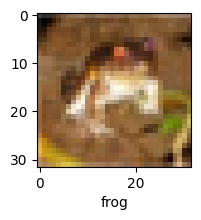

In [18]:
plot_sample(X_train, y_train, 0)

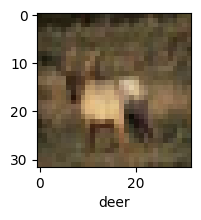

In [19]:
plot_sample(X_train, y_train, 3)

In [21]:
X_train = X_train / 255
X_test = X_test / 255


In [26]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)), 
    layers.Dense(3000, activation='relu'), 
    layers.Dense(1000, activation='relu'), 
    layers.Dense(10, activation='sigmoid')
])

ann.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.3504 - loss: 1.8141
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.4264 - loss: 1.6224
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.4550 - loss: 1.5407
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 21ms/step - accuracy: 0.4772 - loss: 1.4796
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5001 - loss: 1.4289


In [27]:
ann.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4299 - loss: 1.5539


[1.5538830757141113, 0.42989999055862427]

In [30]:
from sklearn.metrics import confusion_matrix, classification_report 
import numpy as np 

y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(i) for i in y_pred]

print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.78      0.15      0.25      1000
           1       0.64      0.56      0.60      1000
           2       0.24      0.71      0.36      1000
           3       0.48      0.08      0.14      1000
           4       0.61      0.12      0.20      1000
           5       0.32      0.56      0.41      1000
           6       0.63      0.33      0.44      1000
           7       0.58      0.49      0.53      1000
           8       0.52      0.72      0.60      1000
           9       0.52      0.57      0.55      1000

    accuracy                           0.43     10000
   macro avg       0.53      0.43      0.41     10000
weighted avg       0.53      0.43      0.41     10000



### CNN
- Conv2D: 
    - padding:
        - valid (default = valid convolution): No padding
        - same: pad such that output is the same as input after convolution 
    - stride: stride(right, down) => default strides=(1,1): move filter 1 by 1

In [ ]:
cnn = models.Sequential([
    # cnn 
    layers.Conv2D(filters=32, kernel_size=(3,3), activation = 'relu', input_shape=(32, 32, 3)), # do not need to specify which filters, only input the number of filters
    layers.MaxPooling2D((2,2)), 

    layers.Conv2D(filters=64, kernel_size=(3,3), activation = 'relu'), 
    layers.MaxPooling2D((2,2)), 
    # dense 
    layers.Flatten(), #input_shape=(32, 32, 3)???
    layers.Dense(64, activation='relu'), 
    layers.Dense(10, activation='softmax') 
    # sigmoid: 1: 0.45, 2:  0.67 
    # softmax (total = 1): 1: (0.45) / (0.45 + 0.67), 2: 0.67 / (0.45 + 0.67)
])

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
cnn.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
cnn.fit(X_train, y_train, epochs =10 )

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.4739 - loss: 1.4590
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6105 - loss: 1.1087
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6594 - loss: 0.9777
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6879 - loss: 0.8967
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7138 - loss: 0.8284
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7321 - loss: 0.7742
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7498 - loss: 0.7213
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7628 - loss: 0.6832
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7776 - loss: 0.6423
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7888 - loss: 0.6062


In [36]:
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6983 - loss: 0.9341


[0.934121310710907, 0.6983000040054321]

In [37]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[4.0171286e-03, 6.8069712e-05, 3.2312323e-03, 9.4620168e-01,
        2.5274331e-04, 2.6773555e-02, 1.6867947e-02, 3.2040294e-05,
        1.5903688e-03, 9.6513703e-04],
       [1.5794390e-04, 9.8229470e-03, 4.5966763e-06, 9.2582769e-07,
        6.8821810e-09, 1.2793025e-08, 5.9765519e-08, 1.4560041e-09,
        9.8995554e-01, 5.8082591e-05],
       [9.4353601e-02, 5.9925042e-02, 1.8841516e-03, 1.6917432e-02,
        3.5770838e-03, 1.2235167e-03, 1.9776779e-03, 1.0207162e-03,
        7.9005033e-01, 2.9070444e-02],
       [8.6882204e-01, 9.3912304e-04, 3.3694763e-02, 5.3401245e-03,
        6.8389224e-03, 1.1602783e-04, 1.6018410e-03, 1.5473817e-03,
        8.1081964e-02, 1.7763386e-05],
       [1.1808895e-06, 1.4690395e-06, 1.5294771e-02, 1.2148705e-02,
        8.1739974e-01, 1.6118234e-03, 1.5349534e-01, 3.8766025e-06,
        4.2630443e-05, 4.5050734e-07]], dtype=float32)

In [46]:
y_classes = [np.argmax(i) for i in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

In [45]:
classes[y_classes[0]]

'cat'

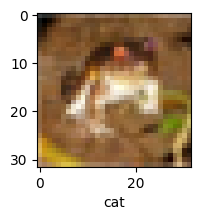

In [47]:
plot_sample(X_test, y_test, 0)